# Étape 2 : Optimisation de l'Agent DQN

## Objectif
Optimiser l'agent DQN (qui a montré de meilleures performances que PPO au notebook 1) pour qu'il dépasse de manière **stable** une récompense moyenne de **200 points** sur 100 épisodes d'évaluation.

## Justification du choix DQN
✓ D'après le notebook 1, **DQN offre de meilleures performances que PPO** sur LunarLander-v3 (espace discret)  
✓ DQN est l'algorithme recommandé pour les espaces d'action discrets  
✓ DQN a montré une bonne convergence avec les paramètres par défaut

## Prérequis
- ✓ Modèle DQN de référence établi à l'étape 1
- ✓ Scores baseline évalués (agent aléatoire et DQN défaut)
- ✓ Dataset et environnement LunarLander-v3 prêts
- ✓ Infrastructure d'entraînement en place

## Méthodologie
- Modifier **un seul hyperparamètre à la fois** pour isoler son effet
- Documenter chaque expérience de façon systématique avec ExperimentTracker
- Lancer 200,000 timesteps par expérience (vs 100,000 au niveau 1) pour meilleure convergence
- Utiliser TensorBoard pour visualiser les courbes de récompense
- Sauvegarder les modèles réussis (score > 200 ET stabilité < 15)
- S'assurer que le score > 200 est **stable** (faible écart-type)

## Hyperparamètres à explorer
1. **learning_rate** : Taux d'apprentissage (exp 1: 0.0005)
2. **buffer_size** : Taille du replay buffer (exp 2: 50000)
3. **gamma** : Facteur de décroissance (futur)
4. **exploration_final_eps** : Epsilon final d'exploration (futur)

In [39]:
# Imports et configuration
import os, datetime
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from pathlib import Path
import gymnasium as gym
from stable_baselines3 import DQN
from stable_baselines3.common.evaluation import evaluate_policy

# Ajouter le chemin src au path si nécessaire
project_root = Path().cwd().parent
if str(project_root / "src") not in sys.path:
    sys.path.insert(0, str(project_root / "src"))

# Créer les répertoires pour les logs et modèles
log_dir = project_root / "data" / "logs"
model_dir = project_root / "models"
log_dir.mkdir(parents=True, exist_ok=True)
model_dir.mkdir(parents=True, exist_ok=True)

print(f"Répertoire des logs: {log_dir}")
print(f"Répertoire des modèles: {model_dir}")

Répertoire des logs: /Users/xaviercoulon/Documents/OC/OC_P11_Entrainement_Agent_RL/data/logs
Répertoire des modèles: /Users/xaviercoulon/Documents/OC/OC_P11_Entrainement_Agent_RL/models


---

## 📊 Scores de Référence (Notebook 1)

D'après le notebook 1 (01_baseline.ipynb), **DQN offre de meilleures performances que PPO** sur LunarLander-v3.  
**⚠️ À remplir après avoir exécuté notebook 1:**

- **Baseline (agent aléatoire)** : ? ± ?
- **DQN (paramètres par défaut)** : ? ± ?
- **PPO (paramètres par défaut)** : ? ± ?

In [40]:
# Charger les résultats du notebook 1
import json
from pathlib import Path

results_file = Path("../data/baseline_results.json")

print("="*70)
print("📊 RÉSULTATS DE REFERENCE (Notebook 1)")
print("="*70 + "\n")

if results_file.exists():
    with open(results_file, "r") as f:
        baseline_results = json.load(f)
    
    print("✓ Résultats chargés depuis notebook 1:\n")
    print(f"🎲 Baseline (Agent Aléatoire):")
    print(f"   Score moyen: {baseline_results['baseline_mean']:.2f} ± {baseline_results['baseline_std']:.2f}")
    
    print(f"\n🎯 DQN (Paramètres par défaut):")
    print(f"   Score moyen: {baseline_results['dqn_mean']:.2f} ± {baseline_results['dqn_std']:.2f}")
    
    print(f"\n🔵 PPO (Paramètres par défaut):")
    print(f"   Score moyen: {baseline_results['ppo_mean']:.2f} ± {baseline_results['ppo_std']:.2f}")
    
    # Déterminer le meilleur
    if baseline_results['dqn_mean'] > baseline_results['ppo_mean']:
        print(f"\n✓ DQN est meilleur de {baseline_results['dqn_mean'] - baseline_results['ppo_mean']:.2f} points")
    else:
        print(f"\n✓ PPO est meilleur de {baseline_results['ppo_mean'] - baseline_results['dqn_mean']:.2f} points")
    
    print("\n" + "="*70)
    print(f"📈 Objectif: Dépasser DQN ({baseline_results['dqn_mean']:.2f}) avec score STABLE > 200")
    print("="*70 + "\n")
else:
    print("⚠️  Fichier baseline_results.json non trouvé")
    print("💡 Exécuter d'abord le notebook 1 et sa dernière cellule")
    baseline_results = {
        "baseline_mean": None,
        "baseline_std": None,
        "dqn_mean": None,
        "dqn_std": None,
        "ppo_mean": None,
        "ppo_std": None
    }

📊 RÉSULTATS DE REFERENCE (Notebook 1)

✓ Résultats chargés depuis notebook 1:

🎲 Baseline (Agent Aléatoire):
   Score moyen: -181.52 ± 100.32

🎯 DQN (Paramètres par défaut):
   Score moyen: 18.13 ± 166.92

🔵 PPO (Paramètres par défaut):
   Score moyen: -88.29 ± 31.60

✓ DQN est meilleur de 106.43 points

📈 Objectif: Dépasser DQN (18.13) avec score STABLE > 200



---

## 🎯 Workflow Recommandé

1. Exécuter cellule **Étape 1** (Setup) une fois
2. Exécuter une cellule d'**Expérience** à la fois
3. Pendant qu'une exp tourne, analyser les précédentes sur **TensorBoard**
4. À la fin, utiliser la section **Analyse Finale** pour comparaison

### 📊 Lancer TensorBoard (dans un terminal séparé)
```bash
cd /Users/xaviercoulon/Documents/OC/OC_P11_Entrainement_Agent_RL
tensorboard --logdir=data/logs --port=6006
```
Puis: http://localhost:6006

**Organisation automatique:** Chaque expérience crée son dossier `exp_X_...` dans `data/logs/`

---

## Utilities pour le suivi des expériences

# ÉTAPE 1: Setup & Configuration

In [41]:
# Fonction pour créer une expérience structurée
class ExperimentTracker:
    """Classe pour documenter et tracker les expériences"""
    
    def __init__(self, exp_name, agent_type, modified_param, param_value, baseline_score=None):
        """
        Args:
            exp_name: nom de l'expérience (ex: "exp_1_learning_rate")
            agent_type: PPO ou DQN
            modified_param: paramètre modifié (ex: "learning_rate")
            param_value: valeur du paramètre
            baseline_score: score de référence pour comparaison
        """
        self.exp_name = exp_name
        self.agent_type = agent_type
        self.modified_param = modified_param
        self.param_value = param_value
        self.baseline_score = baseline_score
        self.exp_dir = log_dir / exp_name
        self.exp_dir.mkdir(parents=True, exist_ok=True)
        self.results = {}
        
    def log_result(self, score_mean, score_std, num_episodes=100):
        """Enregistrer les résultats de l'expérience"""
        self.results = {
            'exp_name': self.exp_name,
            'agent_type': self.agent_type,
            'modified_param': self.modified_param,
            'param_value': str(self.param_value),
            'score_mean': score_mean,
            'score_std': score_std,
            'num_episodes': num_episodes,
            'timestamp': datetime.now().isoformat(),
            'succeeded': score_mean > 200 and score_std < 15
        }
        return self.results
    
    def print_summary(self):
        """Afficher un résumé de l'expérience"""
        if not self.results:
            print("Pas de résultats enregistrés encore")
            return
        
        print(f"\n{'='*60}")
        print(f"Expérience: {self.exp_name}")
        print(f"Agent: {self.agent_type} | Paramètre: {self.modified_param} = {self.param_value}")
        print(f"{'='*60}")
        print(f"Score moyen: {self.results['score_mean']:.2f} ± {self.results['score_std']:.2f}")
        print(f"Objectif: > 200 (écart-type < 15)")
        print(f"✓ RÉUSSI" if self.results['succeeded'] else "✗ Non atteint")
        if self.baseline_score:
            diff = self.results['score_mean'] - self.baseline_score
            print(f"Amélioration vs baseline: {diff:+.2f} ({(diff/self.baseline_score)*100:+.1f}%)")
        print(f"{'='*60}\n")

# Créer un DataFrame global pour tracker toutes les expériences
experiments_df = pd.DataFrame(columns=[
    'exp_name', 'agent_type', 'modified_param', 'param_value', 
    'score_mean', 'score_std', 'num_episodes', 'timestamp', 'succeeded'
])

print("✓ Utilities de suivi chargées")

✓ Utilities de suivi chargées


---

# ÉTAPE 2 : Expériences (Usine à Expériences)

## 📋 Mode d'emploi
- **Une cellule = Une expérience complète**
- Modifier **UN SEUL hyperparamètre** à la fois pour isoler ses effets
- Les résultats s'accumulent dans `experiments_df`
- Visualiser les courbes en temps réel: `tensorboard --logdir=data/logs --port=6006`

## Stratégie d'optimisation
1. **Exp 1**: Augmenter learning_rate (0.0005)
2. **Exp 2**: Augmenter buffer_size (50000)
3. **Exp 3+**: Test gamma, epsilon, batch_size selon résultats

---

## Expérience 1 : Optimisation du Learning Rate

In [42]:
# Expérience 1 : DQN avec Learning Rate optimisé
import gymnasium as gym
from stable_baselines3 import DQN
from stable_baselines3.common.evaluation import evaluate_policy

# 1. Initialiser le tracker

learning_rate = 0.0001  # Valeur testée (augmentée du défaut de 0.0005)

exp_1 = ExperimentTracker(
    exp_name=f"exp_1_dqn_lr_{learning_rate}",
    agent_type="DQN",
    modified_param="learning_rate",
    param_value=learning_rate,
    baseline_score=None  # À remplir avec le score DQN du notebook 1
)

print(f"🚀 Lancement de l'Expérience 1: DQN avec lr={exp_1.param_value}")
print(f"📁 Logs seront sauvegardés dans: {exp_1.exp_dir}\n")

# 2. Créer l'environnement
try:
    env = gym.make("LunarLander-v3")
    env.reset(seed=42)  # ← Fixer graine environnement
    print("✓ Environnement LunarLander-v3 créé (seed=42)\n")
    
    # 3. Créer et entraîner le modèle DQN avec learning_rate optimisé
    print("⏳ Création et entraînement du modèle DQN...")
    num_training_steps = 100_000  # Augmenté pour meilleure convergence
    
    model = DQN(
        "MlpPolicy",
        env,
        learning_rate=learning_rate,        # ← PARAMÈTRE TESTÉ (augmenté du défaut)
        # gamma=0.99,                  # discount factor
        # exploration_fraction=0.1,    # durée de la phase exploration
        # exploration_initial_eps=1.0,
        # exploration_final_eps=0.01,
        # batch_size=32,               # Taille batch standard
        # buffer_size=10000,           # Taille du replay buffer
        # target_update_interval=1000,
        seed=42,                       # ← Fixer graine modèle
        verbose=0,
        tensorboard_log=str(exp_1.exp_dir)
    )
    
    # Entraîner le modèle
    model.learn(total_timesteps=num_training_steps)
    print(f"✓ Entraînement terminé ({num_training_steps} timesteps)\n")
    
    # 4. Évaluer sur 100 épisodes pour robustesse
    print("📊 Évaluation sur 100 épisodes...")
    eval_rewards, eval_std = evaluate_policy(
        model, 
        env, 
        n_eval_episodes=100,
        deterministic=True  # Sans exploration aléatoire
    )
    
    score_mean = eval_rewards
    score_std = eval_std
    print(f"Résultats: {score_mean:.2f} ± {score_std:.2f}\n")
    
    # 5. Enregistrer les résultats
    exp_1.log_result(score_mean, score_std, num_episodes=100)
    exp_1.print_summary()
    
    # 6. Sauvegarder le modèle si prometteur
    if exp_1.results['succeeded']:
        model_path = model_dir / f"exp_1_dqn_lr_{learning_rate}_success_{score_mean:.0f}"
        model.save(str(model_path))
        print(f"✓ Modèle RÉUSSI sauvegardé: {model_path}")
    else:
        print(f"⚠️  Score non atteint")
        print(f"   Objectif: > 200, Obtenu: {score_mean:.2f}")
        print(f"   Écart-type: {score_std:.2f} (objectif: < 15)")
    
    # 7. Ajouter au DataFrame global
    experiments_df_new = pd.DataFrame([exp_1.results])
    globals()['experiments_df'] = pd.concat([experiments_df, experiments_df_new], ignore_index=True)
    print(f"\n✓ Résultats ajoutés au tableau de suivi")
    
    # Fermer l'environnement
    env.close()

except Exception as e:
    print(f"❌ Erreur lors de l'expérience 1:")
    print(f"   {type(e).__name__}: {e}")
    print(f"\n💡 Vérifier:")
    print(f"   - stable_baselines3 est installé: pip install stable-baselines3")
    print(f"   - gymnasium est installé: pip install gymnasium")
    print(f"   - L'environnement LunarLander-v3 est disponible")

🚀 Lancement de l'Expérience 1: DQN avec lr=0.0001
📁 Logs seront sauvegardés dans: /Users/xaviercoulon/Documents/OC/OC_P11_Entrainement_Agent_RL/data/logs/exp_1_dqn_lr_0.0001

✓ Environnement LunarLander-v3 créé (seed=42)

⏳ Création et entraînement du modèle DQN...
✓ Entraînement terminé (100000 timesteps)

📊 Évaluation sur 100 épisodes...


/Users/xaviercoulon/Documents/OC/OC_P11_Entrainement_Agent_RL/.venv/lib/python3.12/site-packages/stable_baselines3/common/evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Résultats: 0.40 ± 168.45


Expérience: exp_1_dqn_lr_0.0001
Agent: DQN | Paramètre: learning_rate = 0.0001
Score moyen: 0.40 ± 168.45
Objectif: > 200 (écart-type < 15)
✗ Non atteint

⚠️  Score non atteint
   Objectif: > 200, Obtenu: 0.40
   Écart-type: 168.45 (objectif: < 15)

✓ Résultats ajoutés au tableau de suivi


## Expérience 2 : Optimisation de la mémoire de replay (buffer_size)

In [43]:
import gymnasium as gym
from stable_baselines3 import DQN
from stable_baselines3.common.evaluation import evaluate_policy

# 1. Initialiser le tracker

buffer_size = 50000  # Valeur testée (augmentée du défaut de 10000)

exp_2 = ExperimentTracker(
    exp_name=f"exp_2_dqn_buffer_{buffer_size}",
    agent_type="DQN",
    modified_param="buffer_size",
    param_value=buffer_size,
    baseline_score=None,  # À remplir avec le score DQN du notebook 1
)

print(f"🚀 Lancement de l'Expérience 2: DQN avec buffer_size={exp_2.param_value}")
print(f"📁 Logs seront sauvegardés dans: {exp_2.exp_dir}\n")

# 2. Créer l'environnement
try:
    env = gym.make("LunarLander-v3")
    env.reset(seed=42)  # ← Fixer graine environnement
    print("✓ Environnement LunarLander-v3 créé (seed=42)\n")

    # 3. Créer et entraîner le modèle DQN avec learning_rate optimisé
    print("⏳ Création et entraînement du modèle DQN...")
    num_training_steps = 100_000  # Augmenté pour meilleure convergence

    model = DQN(
        "MlpPolicy",
        env,
        learning_rate=learning_rate,  # ← PARAMÈTRE TESTÉ (augmenté du défaut)
        # gamma=0.99,                  # discount factor
        # exploration_fraction=0.1,    # durée de la phase exploration
        # exploration_initial_eps=1.0,
        # exploration_final_eps=0.01,
        # batch_size=32,               # Taille batch standard
        buffer_size=buffer_size,       # Taille du replay buffer
        # target_update_interval=1000,
        seed=42,  # ← Fixer graine modèle
        verbose=0,
        tensorboard_log=str(exp_2.exp_dir),
    )

    # Entraîner le modèle
    model.learn(total_timesteps=num_training_steps)
    print(f"✓ Entraînement terminé ({num_training_steps} timesteps)\n")

    # 4. Évaluer sur 100 épisodes pour robustesse
    print("📊 Évaluation sur 100 épisodes...")
    eval_rewards, eval_std = evaluate_policy(
        model,
        env,
        n_eval_episodes=100,
        deterministic=True,  # Sans exploration aléatoire
    )

    score_mean = eval_rewards
    score_std = eval_std
    print(f"Résultats: {score_mean:.2f} ± {score_std:.2f}\n")

    # 5. Enregistrer les résultats
    exp_2.log_result(score_mean, score_std, num_episodes=100)
    exp_2.print_summary()

    # 6. Sauvegarder le modèle si prometteur
    if exp_2.results["succeeded"]:
        model_path = (
            model_dir / f"exp_2_dqn_buffer_{buffer_size}_success_{score_mean:.0f}"
        )
        model.save(str(model_path))
        print(f"✓ Modèle RÉUSSI sauvegardé: {model_path}")
    else:
        print(f"⚠️  Score non atteint")
        print(f"   Objectif: > 200, Obtenu: {score_mean:.2f}")
        print(f"   Écart-type: {score_std:.2f} (objectif: < 15)")

    # 7. Ajouter au DataFrame global
    experiments_df_new = pd.DataFrame([exp_2.results])
    globals()["experiments_df"] = pd.concat(
        [experiments_df, experiments_df_new], ignore_index=True
    )
    print(f"\n✓ Résultats ajoutés au tableau de suivi")

    # Fermer l'environnement
    env.close()

except Exception as e:
    print(f"❌ Erreur lors de l'expérience 2:")
    print(f"   {type(e).__name__}: {e}")
    print(f"\n💡 Vérifier:")
    print(f"   - stable_baselines3 est installé: pip install stable-baselines3")
    print(f"   - gymnasium est installé: pip install gymnasium")
    print(f"   - L'environnement LunarLander-v3 est disponible")

🚀 Lancement de l'Expérience 2: DQN avec buffer_size=50000
📁 Logs seront sauvegardés dans: /Users/xaviercoulon/Documents/OC/OC_P11_Entrainement_Agent_RL/data/logs/exp_2_dqn_buffer_50000

✓ Environnement LunarLander-v3 créé (seed=42)

⏳ Création et entraînement du modèle DQN...
✓ Entraînement terminé (100000 timesteps)

📊 Évaluation sur 100 épisodes...
Résultats: 19.40 ± 157.99


Expérience: exp_2_dqn_buffer_50000
Agent: DQN | Paramètre: buffer_size = 50000
Score moyen: 19.40 ± 157.99
Objectif: > 200 (écart-type < 15)
✗ Non atteint

⚠️  Score non atteint
   Objectif: > 200, Obtenu: 19.40
   Écart-type: 157.99 (objectif: < 15)

✓ Résultats ajoutés au tableau de suivi


## Expérience 3 : Optimisation du batch_size

In [44]:
import gymnasium as gym
from stable_baselines3 import DQN
from stable_baselines3.common.evaluation import evaluate_policy

# 1. Initialiser le tracker

batch_size = 32  # Valeur testée (augmentée du défaut de 32)

exp_3 = ExperimentTracker(
    exp_name=f"exp_3_dqn_batch_{batch_size}",
    agent_type="DQN",
    modified_param="batch_size",
    param_value=batch_size,
    baseline_score=None,  # À remplir avec le score DQN du notebook 1
)

print(f"🚀 Lancement de l'Expérience 3: DQN avec batch_size={exp_3.param_value}")
print(f"📁 Logs seront sauvegardés dans: {exp_3.exp_dir}\n")

# 2. Créer l'environnement
try:
    env = gym.make("LunarLander-v3")
    env.reset(seed=42)  # ← Fixer graine environnement
    print("✓ Environnement LunarLander-v3 créé (seed=42)\n")

    # 3. Créer et entraîner le modèle DQN avec learning_rate optimisé
    print("⏳ Création et entraînement du modèle DQN...")
    num_training_steps = 100_000  # Augmenté pour meilleure convergence

    model = DQN(
        "MlpPolicy",
        env,
        learning_rate=learning_rate,  # ← PARAMÈTRE TESTÉ (augmenté du défaut)
        # gamma=0.99,                  # discount factor
        # exploration_fraction=0.1,    # durée de la phase exploration
        # exploration_initial_eps=1.0,
        # exploration_final_eps=0.01,
        batch_size=batch_size,  # Taille batch testée
        buffer_size=buffer_size,  # Taille du replay buffer
        # target_update_interval=1000,
        seed=42,  # ← Fixer graine modèle
        verbose=0,
        tensorboard_log=str(exp_3.exp_dir),
    )

    # Entraîner le modèle
    model.learn(total_timesteps=num_training_steps)
    print(f"✓ Entraînement terminé ({num_training_steps} timesteps)\n")

    # 4. Évaluer sur 100 épisodes pour robustesse
    print("📊 Évaluation sur 100 épisodes...")
    eval_rewards, eval_std = evaluate_policy(
        model,
        env,
        n_eval_episodes=100,
        deterministic=True,  # Sans exploration aléatoire
    )

    score_mean = eval_rewards
    score_std = eval_std
    print(f"Résultats: {score_mean:.2f} ± {score_std:.2f}\n")

    # 5. Enregistrer les résultats
    exp_3.log_result(score_mean, score_std, num_episodes=100)
    exp_3.print_summary()

    # 6. Sauvegarder le modèle si prometteur
    if exp_3.results["succeeded"]:
        model_path = (
            model_dir / f"exp_3_dqn_batch_{batch_size}_success_{score_mean:.0f}"
        )
        model.save(str(model_path))
        print(f"✓ Modèle RÉUSSI sauvegardé: {model_path}")
    else:
        print(f"⚠️  Score non atteint")
        print(f"   Objectif: > 200, Obtenu: {score_mean:.2f}")
        print(f"   Écart-type: {score_std:.2f} (objectif: < 15)")

    # 7. Ajouter au DataFrame global
    experiments_df_new = pd.DataFrame([exp_3.results])
    globals()["experiments_df"] = pd.concat(
        [experiments_df, experiments_df_new], ignore_index=True
    )
    print(f"\n✓ Résultats ajoutés au tableau de suivi")

    # Fermer l'environnement
    env.close()

except Exception as e:
    print(f"❌ Erreur lors de l'expérience 3:")
    print(f"   {type(e).__name__}: {e}")
    print(f"\n💡 Vérifier:")
    print(f"   - stable_baselines3 est installé: pip install stable-baselines3")
    print(f"   - gymnasium est installé: pip install gymnasium")
    print(f"   - L'environnement LunarLander-v3 est disponible")

🚀 Lancement de l'Expérience 3: DQN avec batch_size=32
📁 Logs seront sauvegardés dans: /Users/xaviercoulon/Documents/OC/OC_P11_Entrainement_Agent_RL/data/logs/exp_3_dqn_batch_32

✓ Environnement LunarLander-v3 créé (seed=42)

⏳ Création et entraînement du modèle DQN...
✓ Entraînement terminé (100000 timesteps)

📊 Évaluation sur 100 épisodes...
Résultats: 19.40 ± 157.99


Expérience: exp_3_dqn_batch_32
Agent: DQN | Paramètre: batch_size = 32
Score moyen: 19.40 ± 157.99
Objectif: > 200 (écart-type < 15)
✗ Non atteint

⚠️  Score non atteint
   Objectif: > 200, Obtenu: 19.40
   Écart-type: 157.99 (objectif: < 15)

✓ Résultats ajoutés au tableau de suivi


### Expérience 4 : Optimisation exploration_fraction

In [45]:
import gymnasium as gym
from stable_baselines3 import DQN
from stable_baselines3.common.evaluation import evaluate_policy

# 1. Initialiser le tracker

exploration_fraction = 0.3  # Valeur testée (augmentée du défaut de 0.1)

exp_4 = ExperimentTracker(
    exp_name=f"exp_4_dqn_exploration_fraction_{exploration_fraction}",
    agent_type="DQN",
    modified_param="exploration_fraction",
    param_value=exploration_fraction,
    baseline_score=None,  # À remplir avec le score DQN du notebook 1
)

print(f"🚀 Lancement de l'Expérience 4: DQN avec exploration_fraction={exp_4.param_value}")
print(f"📁 Logs seront sauvegardés dans: {exp_4.exp_dir}\n")

# 2. Créer l'environnement
try:
    env = gym.make("LunarLander-v3")
    env.reset(seed=42)  # ← Fixer graine environnement
    print("✓ Environnement LunarLander-v3 créé (seed=42)\n")

    # 3. Créer et entraîner le modèle DQN avec learning_rate optimisé
    print("⏳ Création et entraînement du modèle DQN...")
    num_training_steps = 100_000  # Augmenté pour meilleure convergence

    model = DQN(
        "MlpPolicy",
        env,
        learning_rate=learning_rate,  # ← PARAMÈTRE TESTÉ (augmenté du défaut)
        # gamma=0.99,                  # discount factor
        exploration_fraction=exploration_fraction,    # durée de la phase exploration
        # exploration_initial_eps=1.0,
        # exploration_final_eps=0.01,
        batch_size=batch_size,  # Taille batch testée
        buffer_size=buffer_size,  # Taille du replay buffer
        # target_update_interval=1000,
        seed=42,  # ← Fixer graine modèle
        verbose=0,
        tensorboard_log=str(exp_4.exp_dir),
    )

    # Entraîner le modèle
    model.learn(total_timesteps=num_training_steps)
    print(f"✓ Entraînement terminé ({num_training_steps} timesteps)\n")

    # 4. Évaluer sur 100 épisodes pour robustesse
    print("📊 Évaluation sur 100 épisodes...")
    eval_rewards, eval_std = evaluate_policy(
        model,
        env,
        n_eval_episodes=100,
        deterministic=True,  # Sans exploration aléatoire
    )

    score_mean = eval_rewards
    score_std = eval_std
    print(f"Résultats: {score_mean:.2f} ± {score_std:.2f}\n")

    # 5. Enregistrer les résultats
    exp_4.log_result(score_mean, score_std, num_episodes=100)
    exp_4.print_summary()

    # 6. Sauvegarder le modèle si prometteur
    if exp_4.results["succeeded"]:
        model_path = (
            model_dir / f"exp_4_dqn_exploration_fraction_{exploration_fraction}_success_{score_mean:.0f}"
        )
        model.save(str(model_path))
        print(f"✓ Modèle RÉUSSI sauvegardé: {model_path}")
    else:
        print(f"⚠️  Score non atteint")
        print(f"   Objectif: > 200, Obtenu: {score_mean:.2f}")
        print(f"   Écart-type: {score_std:.2f} (objectif: < 15)")

    # 7. Ajouter au DataFrame global
    experiments_df_new = pd.DataFrame([exp_4.results])
    globals()["experiments_df"] = pd.concat(
        [experiments_df, experiments_df_new], ignore_index=True
    )
    print(f"\n✓ Résultats ajoutés au tableau de suivi")

    # Fermer l'environnement
    env.close()

except Exception as e:
    print(f"❌ Erreur lors de l'expérience 4:")
    print(f"   {type(e).__name__}: {e}")
    print(f"\n💡 Vérifier:")
    print(f"   - stable_baselines3 est installé: pip install stable-baselines3")
    print(f"   - gymnasium est installé: pip install gymnasium")
    print(f"   - L'environnement LunarLander-v3 est disponible")

🚀 Lancement de l'Expérience 4: DQN avec exploration_fraction=0.3
📁 Logs seront sauvegardés dans: /Users/xaviercoulon/Documents/OC/OC_P11_Entrainement_Agent_RL/data/logs/exp_4_dqn_exploration_fraction_0.3

✓ Environnement LunarLander-v3 créé (seed=42)

⏳ Création et entraînement du modèle DQN...
✓ Entraînement terminé (100000 timesteps)

📊 Évaluation sur 100 épisodes...
Résultats: 58.26 ± 130.31


Expérience: exp_4_dqn_exploration_fraction_0.3
Agent: DQN | Paramètre: exploration_fraction = 0.3
Score moyen: 58.26 ± 130.31
Objectif: > 200 (écart-type < 15)
✗ Non atteint

⚠️  Score non atteint
   Objectif: > 200, Obtenu: 58.26
   Écart-type: 130.31 (objectif: < 15)

✓ Résultats ajoutés au tableau de suivi


## Expérience 5 : Optimisation du gamma

In [46]:
import gymnasium as gym
from stable_baselines3 import DQN
from stable_baselines3.common.evaluation import evaluate_policy

# 1. Initialiser le tracker

gamma = 0.99  # Valeur testée (augmentée du défaut de 0.99)

exp_5 = ExperimentTracker(
    exp_name=f"exp_5_dqn_gamma_{gamma}",
    agent_type="DQN",
    modified_param="gamma",
    param_value=gamma,
    baseline_score=None,  # À remplir avec le score DQN du notebook 1
)

print(
    f"🚀 Lancement de l'Expérience 5: DQN avec gamma={exp_5.param_value}"
)
print(f"📁 Logs seront sauvegardés dans: {exp_5.exp_dir}\n")

# 2. Créer l'environnement
try:
    env = gym.make("LunarLander-v3")
    env.reset(seed=42)  # ← Fixer graine environnement
    print("✓ Environnement LunarLander-v3 créé (seed=42)\n")

    # 3. Créer et entraîner le modèle DQN avec learning_rate optimisé
    print("⏳ Création et entraînement du modèle DQN...")
    num_training_steps = 100_000  # Augmenté pour meilleure convergence

    model = DQN(
        "MlpPolicy",
        env,
        learning_rate=learning_rate,  # ← PARAMÈTRE TESTÉ (augmenté du défaut)
        gamma=gamma,                  # discount factor
        exploration_fraction=exploration_fraction,  # durée de la phase exploration
        # exploration_initial_eps=1.0,
        # exploration_final_eps=0.01,
        batch_size=batch_size,  # Taille batch testée
        buffer_size=buffer_size,  # Taille du replay buffer
        # target_update_interval=1000,
        seed=42,  # ← Fixer graine modèle
        verbose=0,
        tensorboard_log=str(exp_5.exp_dir),
    )

    # Entraîner le modèle
    model.learn(total_timesteps=num_training_steps)
    print(f"✓ Entraînement terminé ({num_training_steps} timesteps)\n")

    # 4. Évaluer sur 100 épisodes pour robustesse
    print("📊 Évaluation sur 100 épisodes...")
    eval_rewards, eval_std = evaluate_policy(
        model,
        env,
        n_eval_episodes=100,
        deterministic=True,  # Sans exploration aléatoire
    )

    score_mean = eval_rewards
    score_std = eval_std
    print(f"Résultats: {score_mean:.2f} ± {score_std:.2f}\n")

    # 5. Enregistrer les résultats
    exp_5.log_result(score_mean, score_std, num_episodes=100)
    exp_5.print_summary()

    # 6. Sauvegarder le modèle si prometteur
    if exp_5.results["succeeded"]:
        model_path = (
            model_dir
            / f"exp_5_dqn_gamma_{gamma}_success_{score_mean:.0f}"
        )
        model.save(str(model_path))
        print(f"✓ Modèle RÉUSSI sauvegardé: {model_path}")
    else:
        print(f"⚠️  Score non atteint")
        print(f"   Objectif: > 200, Obtenu: {score_mean:.2f}")
        print(f"   Écart-type: {score_std:.2f} (objectif: < 15)")

    # 7. Ajouter au DataFrame global
    experiments_df_new = pd.DataFrame([exp_5.results])
    globals()["experiments_df"] = pd.concat(
        [experiments_df, experiments_df_new], ignore_index=True
    )
    print(f"\n✓ Résultats ajoutés au tableau de suivi")

    # Fermer l'environnement
    env.close()

except Exception as e:
    print(f"❌ Erreur lors de l'expérience 5:")
    print(f"   {type(e).__name__}: {e}")
    print(f"\n💡 Vérifier:")
    print(f"   - stable_baselines3 est installé: pip install stable-baselines3")
    print(f"   - gymnasium est installé: pip install gymnasium")
    print(f"   - L'environnement LunarLander-v3 est disponible")

🚀 Lancement de l'Expérience 5: DQN avec gamma=0.99
📁 Logs seront sauvegardés dans: /Users/xaviercoulon/Documents/OC/OC_P11_Entrainement_Agent_RL/data/logs/exp_5_dqn_gamma_0.99

✓ Environnement LunarLander-v3 créé (seed=42)

⏳ Création et entraînement du modèle DQN...
✓ Entraînement terminé (100000 timesteps)

📊 Évaluation sur 100 épisodes...
Résultats: 58.26 ± 130.31


Expérience: exp_5_dqn_gamma_0.99
Agent: DQN | Paramètre: gamma = 0.99
Score moyen: 58.26 ± 130.31
Objectif: > 200 (écart-type < 15)
✗ Non atteint

⚠️  Score non atteint
   Objectif: > 200, Obtenu: 58.26
   Écart-type: 130.31 (objectif: < 15)

✓ Résultats ajoutés au tableau de suivi


## Expérience 6 : Optimisation du target_update_interval

In [64]:
import gymnasium as gym
from stable_baselines3 import DQN
from stable_baselines3.common.evaluation import evaluate_policy

# 1. Initialiser le tracker

target_update_interval = 500  # Valeur testée (augmentée du défaut de 1000)

exp_6 = ExperimentTracker(
    exp_name=f"exp_6_dqn_target_update_interval_{target_update_interval}",
    agent_type="DQN",
    modified_param="target_update_interval",
    param_value=target_update_interval,
    baseline_score=None,  # À remplir avec le score DQN du notebook 1
)

print(f"🚀 Lancement de l'Expérience 6: DQN avec target_update_interval={target_update_interval}")
print(f"📁 Logs seront sauvegardés dans: {exp_6.exp_dir}\n")

# 2. Créer l'environnement
try:
    env = gym.make("LunarLander-v3")
    env.reset(seed=42)  # ← Fixer graine environnement
    print("✓ Environnement LunarLander-v3 créé (seed=42)\n")

    # 3. Créer et entraîner le modèle DQN avec learning_rate optimisé
    print("⏳ Création et entraînement du modèle DQN...")
    num_training_steps = 300_000  # Augmenté pour meilleure convergence

    model = DQN(
        "MlpPolicy",
        env,
        learning_rate=learning_rate,  # ← PARAMÈTRE TESTÉ (augmenté du défaut)
        gamma=gamma,  # discount factor
        exploration_fraction=exploration_fraction,  # durée de la phase exploration
        # exploration_initial_eps=1.0,
        # exploration_final_eps=0.01,
        batch_size=batch_size,  # Taille batch testée
        buffer_size=buffer_size,  # Taille du replay buffer
        target_update_interval=target_update_interval,
        seed=42,  # ← Fixer graine modèle
        verbose=0,
        tensorboard_log=str(exp_6.exp_dir),
    )

    # Entraîner le modèle
    model.learn(total_timesteps=num_training_steps)
    print(f"✓ Entraînement terminé ({num_training_steps} timesteps)\n")

    # 4. Évaluer sur 100 épisodes pour robustesse
    print("📊 Évaluation sur 100 épisodes...")
    eval_rewards, eval_std = evaluate_policy(
        model,
        env,
        n_eval_episodes=100,
        deterministic=True,  # Sans exploration aléatoire
    )

    score_mean = eval_rewards
    score_std = eval_std
    print(f"Résultats: {score_mean:.2f} ± {score_std:.2f}\n")

    # 5. Enregistrer les résultats
    exp_6.log_result(score_mean, score_std, num_episodes=100)
    exp_6.print_summary()

    # 6. Sauvegarder le modèle si prometteur
    if exp_6.results["succeeded"]:
        model_path = model_dir / f"exp_6_dqn_target_update_interval_{target_update_interval}_success_{score_mean:.0f}"
        model.save(str(model_path))
        print(f"✓ Modèle RÉUSSI sauvegardé: {model_path}")
    else:
        print(f"⚠️  Score non atteint")
        print(f"   Objectif: > 200, Obtenu: {score_mean:.2f}")
        print(f"   Écart-type: {score_std:.2f} (objectif: < 15)")

    # 7. Ajouter au DataFrame global
    experiments_df_new = pd.DataFrame([exp_6.results])
    globals()["experiments_df"] = pd.concat(
        [experiments_df, experiments_df_new], ignore_index=True
    )
    print(f"\n✓ Résultats ajoutés au tableau de suivi")

    # Fermer l'environnement
    env.close()

except Exception as e:
    print(f"❌ Erreur lors de l'expérience 6:")
    print(f"   {type(e).__name__}: {e}")
    print(f"\n💡 Vérifier:")
    print(f"   - stable_baselines3 est installé: pip install stable-baselines3")
    print(f"   - gymnasium est installé: pip install gymnasium")
    print(f"   - L'environnement LunarLander-v3 est disponible")

🚀 Lancement de l'Expérience 6: DQN avec target_update_interval=500
📁 Logs seront sauvegardés dans: /Users/xaviercoulon/Documents/OC/OC_P11_Entrainement_Agent_RL/data/logs/exp_6_dqn_target_update_interval_500

✓ Environnement LunarLander-v3 créé (seed=42)

⏳ Création et entraînement du modèle DQN...
✓ Entraînement terminé (300000 timesteps)

📊 Évaluation sur 100 épisodes...
Résultats: 206.61 ± 86.03


Expérience: exp_6_dqn_target_update_interval_500
Agent: DQN | Paramètre: target_update_interval = 500
Score moyen: 206.61 ± 86.03
Objectif: > 200 (écart-type < 15)
✗ Non atteint

⚠️  Score non atteint
   Objectif: > 200, Obtenu: 206.61
   Écart-type: 86.03 (objectif: < 15)

✓ Résultats ajoutés au tableau de suivi


## Expérience 7 : Optimisation du train_freq


In [80]:
import gymnasium as gym
from stable_baselines3 import DQN
from stable_baselines3.common.evaluation import evaluate_policy

# 1. Initialiser le tracker

train_freq = 1  # Valeur testée (augmentée du défaut de 4)

exp_7 = ExperimentTracker(
    exp_name=f"exp_7_dqn_train_freq_{train_freq}",
    agent_type="DQN",
    modified_param="train_freq",
    param_value=f"{train_freq}",
    baseline_score=None,  # À remplir avec le score DQN du notebook 1
)

print(
    f"🚀 Lancement de l'Expérience 7: DQN avec train_freq = {train_freq}"
)
print(f"📁 Logs seront sauvegardés dans: {exp_7.exp_dir}\n")

# 2. Créer l'environnement
try:
    env = gym.make("LunarLander-v3")
    env.reset(seed=42)  # ← Fixer graine environnement
    print("✓ Environnement LunarLander-v3 créé (seed=42)\n")

    # 3. Créer et entraîner le modèle DQN avec learning_rate optimisé
    print("⏳ Création et entraînement du modèle DQN...")
    num_training_steps = 300_000  # Augmenté pour meilleure convergence

    model = DQN(
        "MlpPolicy",
        env,
        learning_rate=learning_rate,
        train_freq=train_freq,
		gamma=gamma,  # discount factor
        exploration_fraction=exploration_fraction,  # durée de la phase exploration
        batch_size=batch_size,  # Taille batch testée
        buffer_size=buffer_size,  # Taille du replay buffer
        target_update_interval=target_update_interval,
        seed=42,  # ← Fixer graine modèle
        verbose=0,
        tensorboard_log=str(exp_7.exp_dir),
    )

    # Entraîner le modèle
    model.learn(total_timesteps=num_training_steps)
    print(f"✓ Entraînement terminé ({num_training_steps} timesteps)\n")

    # 4. Évaluer sur 100 épisodes pour robustesse
    print("📊 Évaluation sur 100 épisodes...")
    eval_rewards, eval_std = evaluate_policy(
        model,
        env,
        n_eval_episodes=100,
        deterministic=True,  # Sans exploration aléatoire
    )

    score_mean = eval_rewards
    score_std = eval_std
    print(f"Résultats: {score_mean:.2f} ± {score_std:.2f}\n")

    # 5. Enregistrer les résultats
    exp_7.log_result(score_mean, score_std, num_episodes=100)
    exp_7.print_summary()

    # 6. Sauvegarder le modèle si prometteur
    if exp_7.results["succeeded"]:
        model_path = (
            model_dir
            / f"exp_7_dqn_train_freq_{train_freq}_success_{score_mean:.0f}"
        )
        model.save(str(model_path))
        print(f"✓ Modèle RÉUSSI sauvegardé: {model_path}")
    else:
        print(f"⚠️  Score non atteint")
        print(f"   Objectif: > 200, Obtenu: {score_mean:.2f}")
        print(f"   Écart-type: {score_std:.2f} (objectif: < 15)")

    # 7. Ajouter au DataFrame global
    experiments_df_new = pd.DataFrame([exp_7.results])
    globals()["experiments_df"] = pd.concat(
        [experiments_df, experiments_df_new], ignore_index=True
    )
    print(f"\n✓ Résultats ajoutés au tableau de suivi")

    # Fermer l'environnement
    env.close()

except Exception as e:
    print(f"❌ Erreur lors de l'expérience 7:")
    print(f"   {type(e).__name__}: {e}")
    print(f"\n💡 Vérifier:")
    print(f"   - stable_baselines3 est installé: pip install stable-baselines3")
    print(f"   - gymnasium est installé: pip install gymnasium")
    print(f"   - L'environnement LunarLander-v3 est disponible")

🚀 Lancement de l'Expérience 7: DQN avec train_freq = 1
📁 Logs seront sauvegardés dans: /Users/xaviercoulon/Documents/OC/OC_P11_Entrainement_Agent_RL/data/logs/exp_7_dqn_train_freq_1

✓ Environnement LunarLander-v3 créé (seed=42)

⏳ Création et entraînement du modèle DQN...
✓ Entraînement terminé (300000 timesteps)

📊 Évaluation sur 100 épisodes...


/Users/xaviercoulon/Documents/OC/OC_P11_Entrainement_Agent_RL/.venv/lib/python3.12/site-packages/stable_baselines3/common/evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Résultats: 202.70 ± 57.11


Expérience: exp_7_dqn_train_freq_1
Agent: DQN | Paramètre: train_freq = 1
Score moyen: 202.70 ± 57.11
Objectif: > 200 (écart-type < 15)
✗ Non atteint

⚠️  Score non atteint
   Objectif: > 200, Obtenu: 202.70
   Écart-type: 57.11 (objectif: < 15)

✓ Résultats ajoutés au tableau de suivi


## Expérience 8 : Optimisation du learning starts


In [85]:
import gymnasium as gym
from stable_baselines3 import DQN
from stable_baselines3.common.evaluation import evaluate_policy

# 1. Initialiser le tracker

learning_starts = 5000

exp_8 = ExperimentTracker(
    exp_name=f"exp_8_dqn_learning_starts_{learning_starts}",
    agent_type="DQN",
    modified_param="learning_starts",
    param_value=f"{learning_starts}",
    baseline_score=None,  # À remplir avec le score DQN du notebook 1
)

print(f"🚀 Lancement de l'Expérience 8: DQN avec learning_starts = {learning_starts}")
print(f"📁 Logs seront sauvegardés dans: {exp_8.exp_dir}\n")

# 2. Créer l'environnement
try:
    env = gym.make("LunarLander-v3")
    env.reset(seed=42)  # ← Fixer graine environnement
    print("✓ Environnement LunarLander-v3 créé (seed=42)\n")

    # 3. Créer et entraîner le modèle DQN avec learning_rate optimisé
    print("⏳ Création et entraînement du modèle DQN...")
    num_training_steps = 300_000  # Augmenté pour meilleure convergence

    model = DQN(
        "MlpPolicy",
        env,
        learning_rate=learning_rate,
        learning_starts=learning_starts,
        train_freq=train_freq,
        gamma=gamma,  # discount factor
        exploration_fraction=exploration_fraction,  # durée de la phase exploration
        batch_size=batch_size,  # Taille batch testée
        buffer_size=buffer_size,  # Taille du replay buffer
        target_update_interval=target_update_interval,
        seed=42,  # ← Fixer graine modèle
        verbose=0,
        tensorboard_log=str(exp_8.exp_dir),
    )

    # Entraîner le modèle
    model.learn(total_timesteps=num_training_steps)
    print(f"✓ Entraînement terminé ({num_training_steps} timesteps)\n")

    # 4. Évaluer sur 100 épisodes pour robustesse
    print("📊 Évaluation sur 100 épisodes...")
    eval_rewards, eval_std = evaluate_policy(
        model,
        env,
        n_eval_episodes=100,
        deterministic=True,  # Sans exploration aléatoire
    )

    score_mean = eval_rewards
    score_std = eval_std
    print(f"Résultats: {score_mean:.2f} ± {score_std:.2f}\n")

    # 5. Enregistrer les résultats
    exp_8.log_result(score_mean, score_std, num_episodes=100)
    exp_8.print_summary()

    # 6. Sauvegarder le modèle si prometteur
    if exp_8.results["succeeded"]:
        model_path = (
            model_dir / f"exp_8_dqn_learning_starts_{learning_starts}_success_{score_mean:.0f}"
        )
        model.save(str(model_path))
        print(f"✓ Modèle RÉUSSI sauvegardé: {model_path}")
    else:
        print(f"⚠️  Score non atteint")
        print(f"   Objectif: > 200, Obtenu: {score_mean:.2f}")
        print(f"   Écart-type: {score_std:.2f} (objectif: < 15)")

    # 7. Ajouter au DataFrame global
    experiments_df_new = pd.DataFrame([exp_8.results])
    globals()["experiments_df"] = pd.concat(
        [experiments_df, experiments_df_new], ignore_index=True
    )
    print(f"\n✓ Résultats ajoutés au tableau de suivi")

    # Fermer l'environnement
    env.close()

except Exception as e:
    print(f"❌ Erreur lors de l'expérience 8:")
    print(f"   {type(e).__name__}: {e}")
    print(f"\n💡 Vérifier:")
    print(f"   - stable_baselines3 est installé: pip install stable-baselines3")
    print(f"   - gymnasium est installé: pip install gymnasium")
    print(f"   - L'environnement LunarLander-v3 est disponible")

🚀 Lancement de l'Expérience 8: DQN avec learning_starts = 5000
📁 Logs seront sauvegardés dans: /Users/xaviercoulon/Documents/OC/OC_P11_Entrainement_Agent_RL/data/logs/exp_8_dqn_learning_starts_5000

✓ Environnement LunarLander-v3 créé (seed=42)

⏳ Création et entraînement du modèle DQN...
✓ Entraînement terminé (300000 timesteps)

📊 Évaluation sur 100 épisodes...
Résultats: 241.33 ± 36.91


Expérience: exp_8_dqn_learning_starts_5000
Agent: DQN | Paramètre: learning_starts = 5000
Score moyen: 241.33 ± 36.91
Objectif: > 200 (écart-type < 15)
✗ Non atteint

⚠️  Score non atteint
   Objectif: > 200, Obtenu: 241.33
   Écart-type: 36.91 (objectif: < 15)

✓ Résultats ajoutés au tableau de suivi


## Sauvegarde du modèle final


In [ ]:
# 🎯 Sauvegarder le modèle EXP_8 avec la méthode native Stable-Baselines3
# (compresse les poids du réseau + hyperparamètres dans un .zip)

import json
from datetime import datetime

# Chemin de sauvegarde du modèle
model_save_path = model_dir / "modele_final"

print("\n" + "="*70)
print("💾 SAUVEGARDE DU MODÈLE FINAL")
print("="*70)
print(f"\n📁 Chemin de sauvegarde: {model_save_path}\n")

try:
    # Sauvegarder le modèle (crée un .zip avec poids + hyperparamètres)
    model.save(str(model_save_path))
    print(f"✓ Modèle sauvegardé avec succès!")
    print(f"   Fichier: {model_save_path}.zip")
    
    # Créer un fichier de metadata pour l'API
    metadata = {
        "model_name": "modele_final",
        "model_type": "DQN",
        "timestamp_saved": datetime.now().isoformat(),
        
        # Performance metrics
        "performance": {
            "score_mean": float(score_mean),
            "score_std": float(score_std),
            "num_eval_episodes": 100,
            "training_timesteps": num_training_steps,
        },
        
        # Hyperparamètres utilisés
        "hyperparameters": {
            "learning_rate": float(learning_rate),
            "learning_starts": int(learning_starts),
            "buffer_size": int(buffer_size),
            "batch_size": int(batch_size),
            "gamma": float(gamma),
            "exploration_fraction": float(exploration_fraction),
            "target_update_interval": int(target_update_interval),
            "train_freq": int(train_freq),
        },
        
        # Informations d'utilisation
        "usage": {
            "environment": "LunarLander-v3",
            "load_command": f"from stable_baselines3 import DQN\nmodel = DQN.load('{model_save_path}')",
            "inference_example": "obs, info = env.reset()\naction, _states = model.predict(obs, deterministic=True)\nobs, rewards, terminated, truncated, info = env.step(action)"
        }
    }
    
    # Sauvegarder le JSON de metadata
    metadata_path = model_dir / "modele_final_metadata.json"
    with open(metadata_path, 'w') as f:
        json.dump(metadata, f, indent=2)
    
    print(f"✓ Metadata sauvegardées: {metadata_path}\n")
    
    print("📋 Résumé for l'API:")
    print(f"   • Type: DQN pour LunarLander-v3")
    print(f"   • Performance: {score_mean:.2f} ± {score_std:.2f}")
    print(f"   • Hyperparamètre clé: learning_starts={learning_starts}")
    print(f"   • Fichier de chargement: {model_save_path}.zip")
    print("="*70 + "\n")
    
except Exception as e:
    print(f"❌ Erreur lors de la sauvegarde:")
    print(f"   {type(e).__name__}: {e}")


💾 SAUVEGARDE DU MODÈLE FINAL

📁 Chemin de sauvegarde: /Users/xaviercoulon/Documents/OC/OC_P11_Entrainement_Agent_RL/models/modele_final

✓ Modèle sauvegardé avec succès!
   Fichier: /Users/xaviercoulon/Documents/OC/OC_P11_Entrainement_Agent_RL/models/modele_final.zip
✓ Metadata sauvegardées: /Users/xaviercoulon/Documents/OC/OC_P11_Entrainement_Agent_RL/models/modele_final_metadata.json

📋 Résumé for l'API:
   • Type: DQN pour LunarLander-v3
   • Performance: 241.33 ± 36.91
   • Hyperparamètre clé: learning_starts=5000
   • Fichier de chargement: /Users/xaviercoulon/Documents/OC/OC_P11_Entrainement_Agent_RL/models/modele_final.zip



In [82]:
# ÉTAPE 3.1 : Afficher le tableau récapitulatif des expériences
print("\n" + "="*70)
print("📊 TABLEAU RÉCAPITULATIF - TOUTES LES EXPÉRIENCES")
print("="*70 + "\n")

if len(experiments_df) > 0:
    print(experiments_df.to_string(index=False))
    
    # Identifier le meilleur modèle
    best_idx = experiments_df['score_mean'].idxmax()
    best_exp = experiments_df.loc[best_idx]
    
    print("\n" + "="*70)
    print("🏆 MEILLEUR MODÈLE")
    print("="*70)
    print(f"Expérience: {best_exp['exp_name']}")
    print(f"Score moyen: {best_exp['score_mean']:.2f} ± {best_exp['score_std']:.2f}")
    print(f"Paramètre: {best_exp['modified_param']} = {best_exp['param_value']}")
    
    if best_exp['succeeded']:
        print(f"✓ Objectif atteint (score > 200 et stabilité < 15)")
    else:
        print(f"⚠️  Objectif non atteint")
    print("="*70 + "\n")
else:
    print("⚠️  Aucune expérience exécutée encore")


📊 TABLEAU RÉCAPITULATIF - TOUTES LES EXPÉRIENCES

                             exp_name agent_type         modified_param                                                param_value  score_mean   score_std num_episodes                  timestamp succeeded
                  exp_1_dqn_lr_0.0001        DQN          learning_rate                                                     0.0001    0.401824  168.452847          100 2026-03-07T14:24:57.549239     False
               exp_2_dqn_buffer_50000        DQN            buffer_size                                                      50000    19.40418  157.989927          100 2026-03-07T14:25:34.803080     False
                   exp_3_dqn_batch_32        DQN             batch_size                                                         32    19.40418  157.989927          100 2026-03-07T14:26:11.349166     False
   exp_4_dqn_exploration_fraction_0.3        DQN   exploration_fraction                                                        0.

## ÉTAPE 3.2 : Visualisation de la Comparaison


📊 Génération des graphiques de comparaison...



/var/folders/3c/rxlj8ssj4nvdn48ggmlhw1680000gn/T/ipykernel_48716/3043725089.py:78: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/Users/xaviercoulon/Documents/OC/OC_P11_Entrainement_Agent_RL/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


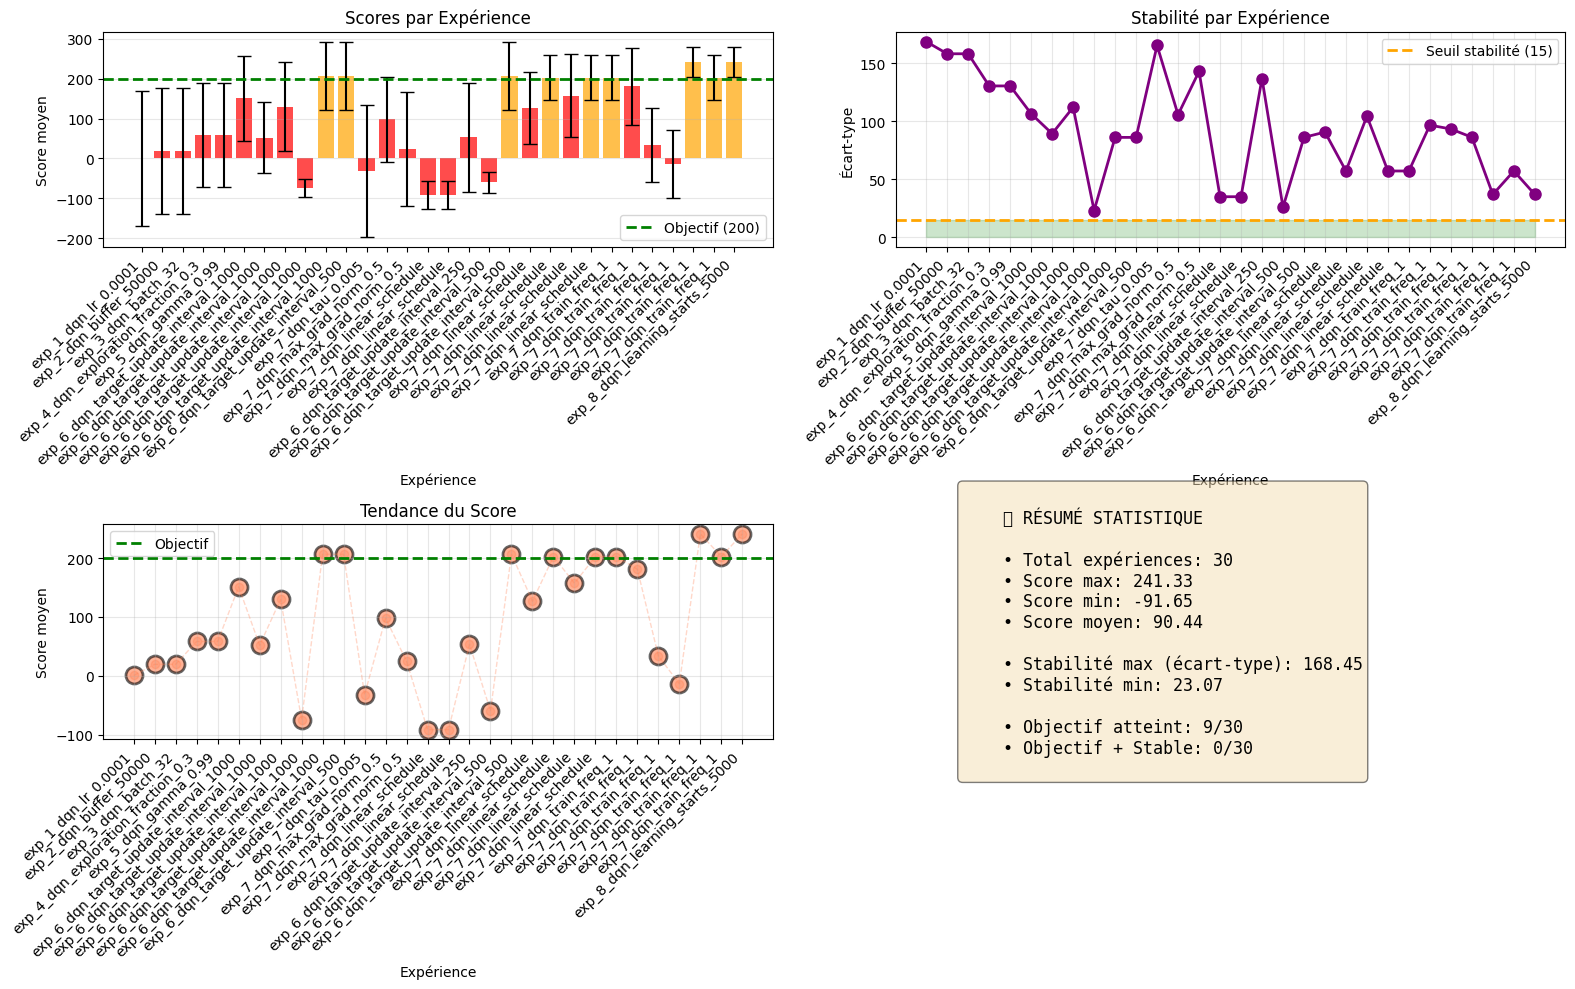

✓ Visualisation complète


In [83]:
# ÉTAPE 3.2 : Visualiser la comparaison des expériences
print("\n📊 Génération des graphiques de comparaison...\n")

def plot_experiments_comparison():
    """Créer des graphiques de comparaison des expériences"""
    if len(experiments_df) == 0:
        print("❌ Aucune expérience à comparer - exécuter d'abord les cellules d'expériences")
        return
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Données
    exp_names = experiments_df['exp_name']
    scores = experiments_df['score_mean']
    stds = experiments_df['score_std']
    params = experiments_df['param_value']
    
    # Graphique 1 : Bar chart - Scores par expérience
    ax = axes[0, 0]
    colors = ['green' if s > 200 and stds.iloc[i] < 15 else 'orange' if s > 200 else 'red' 
              for i, s in enumerate(scores)]
    ax.bar(range(len(exp_names)), scores, yerr=stds, capsize=5, alpha=0.7, color=colors)
    ax.axhline(y=200, color='green', linestyle='--', label='Objectif (200)', linewidth=2)
    ax.set_xlabel('Expérience')
    ax.set_ylabel('Score moyen')
    ax.set_title('Scores par Expérience')
    ax.set_xticks(range(len(exp_names)))
    ax.set_xticklabels(exp_names, rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    # Graphique 2 : Stabilité (écart-type)
    ax = axes[0, 1]
    ax.plot(range(len(exp_names)), stds, 'o-', linewidth=2, markersize=8, color='purple')
    ax.axhline(y=15, color='orange', linestyle='--', label='Seuil stabilité (15)', linewidth=2)
    ax.fill_between(range(len(exp_names)), 0, 15, alpha=0.2, color='green')
    ax.set_xlabel('Expérience')
    ax.set_ylabel('Écart-type')
    ax.set_title('Stabilité par Expérience')
    ax.set_xticks(range(len(exp_names)))
    ax.set_xticklabels(exp_names, rotation=45, ha='right')
    ax.legend()
    ax.grid(alpha=0.3)
    
    # Graphique 3 : Évolution du score
    ax = axes[1, 0]
    ax.scatter(range(len(exp_names)), scores, s=150, alpha=0.6, color='coral', edgecolor='black', linewidth=2)
    ax.plot(range(len(exp_names)), scores, 'o--', alpha=0.3, color='coral', linewidth=1)
    ax.axhline(y=200, color='green', linestyle='--', label='Objectif', linewidth=2)
    ax.set_xlabel('Expérience')
    ax.set_ylabel('Score moyen')
    ax.set_title('Tendance du Score')
    ax.set_xticks(range(len(exp_names)))
    ax.set_xticklabels(exp_names, rotation=45, ha='right')
    ax.legend()
    ax.grid(alpha=0.3)
    
    # Graphique 4 : Résumé stat
    ax = axes[1, 1]
    ax.axis('off')
    summary_text = f"""
    📈 RÉSUMÉ STATISTIQUE
    
    • Total expériences: {len(experiments_df)}
    • Score max: {scores.max():.2f}
    • Score min: {scores.min():.2f}
    • Score moyen: {scores.mean():.2f}
    
    • Stabilité max (écart-type): {stds.max():.2f}
    • Stabilité min: {stds.min():.2f}
    
    • Objectif atteint: {(scores > 200).sum()}/{ len(experiments_df)}
    • Objectif + Stable: {((scores > 200) & (stds < 15)).sum()}/{len(experiments_df)}
    """
    ax.text(0.1, 0.5, summary_text, fontsize=12, verticalalignment='center',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5), family='monospace')
    
    plt.tight_layout()
    plt.show()

# Exécuter la visualisation
plot_experiments_comparison()
print("✓ Visualisation complète")

---

# ÉTAPE 3: Analyse & Résultats Finaux

## 📊 Résumé des Expériences

À remplir après exécution de toutes les expériences. Le tableau `experiments_df` sera automatiquement mis à jour.